# The template anchor: a half-pixel bug, the fix, and what it changes

## What this notebook is

When a seed's template is cut, three numbers decide what the search actually looks for: the
**size** of the crop, and the **x, y** of its centre. This notebook is about the centre.

There are three ways the repo can pick it, and this notebook walks all three from first
principles, on real seeds, with every intermediate number printed:

| arm | where the template centre comes from | who uses it |
|---|---|---|
| **A · click** | the pathologist's click, unchanged | `gated_seed_precision_at_k/` — **production today** (`DECISIONS.md` D8 amendment) |
| **B · component (as implemented)** | `(x0 + x1) / 2` of the accepted component's bounding box | `production_seed_precision_at_k/` — pinned here as `tightened_template_box_asis`, since the library has been corrected |
| **C · component (corrected)** | `(x0 + x1 - 1) / 2` of the same bounding box | `seed_selection.tightened_template_box`, corrected 2026-09-10 — **current** (`D8_TEMPLATE_ANCHOR.md`) |

B and C differ by exactly **half a pixel per axis**. That sounds like nothing. It is 23% of the
median recentring distance, it points the same way every time, and it costs arm B a geometric
guarantee that arm C keeps. It also lands on **9 of the 14** seeds behind every `precision_at_k`
result in this repo.

All three arms use the **same containment gate**, so on any given ROI they draw the *same*
annotation at the *same* size. The centre is the only thing that varies. That is what makes this
a clean comparison, unlike the ungated variants.

## How to read this notebook

Part 1–5 are the argument, built on synthetic examples where the right answer is known by
construction, so nothing rests on trusting the pipeline. Part 6–9 are the same argument on real
seeds. Part 10 is the population measurement. Part 11 runs the full detector end to end — and is
explicitly *not* the evidence, for reasons stated there.

In [1]:
import gc
import os
import sys
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Rectangle
from skimage.measure import label, regionprops

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import compare as cp
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils import viz
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
plt.rcParams['figure.facecolor'] = 'white'

NB_T0 = time.time()
FIGDIR = 'figures_anchor'
os.makedirs(FIGDIR, exist_ok=True)

IMAGES_DIR = '../images/extra_valid'
W = tm.BASE_SIZE                 # 51 -- the Otsu window, the annotation box made odd
HALF = W // 2                    # 25 -- the click is always this pixel of the window
CFG = fs.FSConfig(channel='hematoxylin_od', base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=4, flips=(False, True))
BORDER = CFG.patch_size // 2     # 36

ARMS = ('A_click', 'B_component_asis', 'C_component_fixed')
ARM_LABEL = {'A_click': 'A · click (production today)',
             'B_component_asis': 'B · component, as implemented',
             'C_component_fixed': 'C · component, corrected'}
ARM_COLOR = {'A_click': '#0b8a3c', 'B_component_asis': '#1b63d6', 'C_component_fixed': '#c2185b'}


def savefig(fig, name):
    p = f'{FIGDIR}/{name}'
    fig.savefig(p, dpi=130, bbox_inches='tight', facecolor='white')
    plt.show(); plt.close(fig)
    print(f'  -> {p}')


print(f'Otsu window W = {W} px, so the click always sits at patch pixel ({HALF}, {HALF})')
print(f'template patch read size = {CFG.patch_size} px, border margin = {BORDER} px')

Otsu window W = 51 px, so the click always sits at patch pixel (25, 25)
template patch read size = 73 px, border margin = 36 px


---

## Part 1 — Two different things both called "the centre of a box"

`skimage.measure.regionprops` reports a bounding box as `(min_row, min_col, max_row, max_col)`,
and it is **half-open**: the last index is *excluded*.

So a box reported as `x0 = 6, x1 = 51` covers columns **6, 7, 8, … 50**. That is 45 columns, and
column 51 is not part of it.

Now ask where its centre is. There are two honest answers, and they are not the same number:

- **The area answer.** Think of column `i` as occupying the continuous strip from `i` to `i+1`.
  Then the box occupies `[6.0, 51.0)`, a strip 45 units wide, and its midpoint is
  `(6 + 51) / 2 = 28.5`. That value sits on the *seam* between column 28 and column 29.
- **The pixel answer.** Think of column `i` as a single point. Then the box is the list of points
  6 … 50, and the middle one is `(6 + 50) / 2 = 28.0` — column 28, an actual pixel.

The two answers always differ by exactly **0.5**, because `x1` (excluded) is one more than the
last real column `x1 - 1`.

Neither is wrong on its own. What makes one of them wrong *here* is what happens to the number
next.

In [2]:
# One box, both answers, spelled out.
x0, x1 = 6, 51
columns = list(range(x0, x1))
print(f'bbox reported as x0={x0}, x1={x1}  (half-open)')
print(f'  columns actually covered : {columns[0]} .. {columns[-1]}   ({len(columns)} of them)')
print(f'  column {x1} is NOT covered')
print()
print(f'  area answer  (x0 + x1) / 2      = ({x0} + {x1}) / 2      = {(x0 + x1) / 2}'
      f'   <- a seam between two pixels')
print(f'  pixel answer (x0 + x1 - 1) / 2  = ({x0} + {x1} - 1) / 2  = {(x0 + x1 - 1) / 2}'
      f'   <- an actual pixel')
print()
print(f'  difference = {(x0 + x1) / 2 - (x0 + x1 - 1) / 2} px, always, for any box')

bbox reported as x0=6, x1=51  (half-open)
  columns actually covered : 6 .. 50   (45 of them)
  column 51 is NOT covered

  area answer  (x0 + x1) / 2      = (6 + 51) / 2      = 28.5   <- a seam between two pixels
  pixel answer (x0 + x1 - 1) / 2  = (6 + 51 - 1) / 2  = 28.0   <- an actual pixel

  difference = 0.5 px, always, for any box


### The same thing, drawn

Below, one row of pixels. The shaded cells are the box (`x0 = 6`, `x1 = 51`, drawn truncated).
The **pixel answer** lands on the middle shaded cell. The **area answer** lands half a cell to
its right, on the boundary between two cells — a position that is not any pixel.

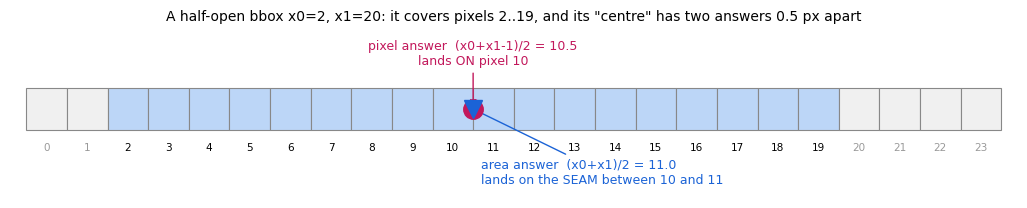

  -> figures_anchor/part1_two_centres.png


In [3]:
fig, ax = plt.subplots(figsize=(13, 2.2))
lo, hi = 2, 20                     # a small box, so the drawing is legible
cells = range(0, 24)
for i in cells:
    inside = lo <= i < hi
    ax.add_patch(Rectangle((i, 0), 1, 1, facecolor='#bcd6f7' if inside else '#f0f0f0',
                           edgecolor='#888', linewidth=0.8))
    ax.text(i + 0.5, -0.28, str(i), ha='center', va='top', fontsize=7.5,
            color='black' if inside else '#999')
pix = (lo + hi - 1) / 2
area = (lo + hi) / 2
ax.plot([pix + 0.5], [0.5], marker='o', markersize=14, color='#c2185b', zorder=5)
ax.annotate(f'pixel answer  (x0+x1-1)/2 = {pix}\nlands ON pixel {int(pix)}',
            xy=(pix + 0.5, 0.5), xytext=(pix + 0.5, 1.55), ha='center', fontsize=9,
            color='#c2185b', arrowprops=dict(arrowstyle='->', color='#c2185b'))
ax.plot([area + 0.0], [0.5], marker='v', markersize=13, color='#1b63d6', zorder=5)
ax.annotate(f'area answer  (x0+x1)/2 = {area}\nlands on the SEAM between {int(area)-1} and {int(area)}',
            xy=(area, 0.5), xytext=(area + 0.2, -1.25), ha='left', fontsize=9,
            color='#1b63d6', arrowprops=dict(arrowstyle='->', color='#1b63d6'))
ax.set_xlim(-0.4, 24.4); ax.set_ylim(-1.6, 2.4); ax.axis('off')
ax.set_title(f'A half-open bbox x0={lo}, x1={hi}: it covers pixels {lo}..{hi-1}, and its '
             f'"centre" has two answers 0.5 px apart', fontsize=10)
savefig(fig, 'part1_two_centres.png')

---

## Part 2 — Which answer does the pipeline actually need?

The anchor is not printed on a report. It is handed to `template_match.read_padded_patch`, which
does exactly this:

```python
half = patch_size // 2
ix, iy = int(round(cx)), int(round(cy))
return img[iy - half : iy + half + 1, ix - half : ix + half + 1]
```

Read that carefully. It **rounds the anchor to an integer**, then takes a window of `half` pixels
on each side *plus the pixel itself*. The window has an odd side length and there is a single
centre pixel: `ix`.

That is the **pixel** convention. `read_padded_patch` has no notion of a seam between pixels — it
cannot centre a crop on one. Handing it the area answer means handing it a number it will round,
and the rounding is where the half pixel turns into a whole one.

So the anchor must be computed the pixel way: `(x0 + x1 - 1) / 2`.

In [4]:
# Demonstrate the convention directly: a marked pixel, and where read_padded_patch lands.
img = np.zeros((40, 40), np.float32)
img[20, 20] = 1.0                       # a single lit pixel at row 20, col 20
for anchor in (20.0, 20.4, 20.5, 20.6, 21.0):
    p = tm.read_padded_patch(img, anchor, 20.0, 7)     # 7x7 window, centre index 3
    where = np.argwhere(p > 0)
    at_centre = bool(p[3, 3] > 0)
    print(f'anchor cx={anchor:<5} -> int(round) = {int(round(anchor)):2d} | '
          f'lit pixel sits at window {where.tolist()} | is it the centre pixel? {at_centre}')
print()
print('The window is 7 px wide with one centre cell (index 3). An anchor of 20.5 does NOT')
print('produce a window centred between pixels -- it rounds, and the lit pixel moves off centre.')

anchor cx=20.0  -> int(round) = 20 | lit pixel sits at window [[3, 3]] | is it the centre pixel? True
anchor cx=20.4  -> int(round) = 20 | lit pixel sits at window [[3, 3]] | is it the centre pixel? True
anchor cx=20.5  -> int(round) = 20 | lit pixel sits at window [[3, 3]] | is it the centre pixel? True
anchor cx=20.6  -> int(round) = 21 | lit pixel sits at window [[3, 2]] | is it the centre pixel? False
anchor cx=21.0  -> int(round) = 21 | lit pixel sits at window [[3, 2]] | is it the centre pixel? False

The window is 7 px wide with one centre cell (index 3). An anchor of 20.5 does NOT
produce a window centred between pixels -- it rounds, and the lit pixel moves off centre.


---

## Part 3 — The bug, verified against the live function

Until 2026-09-10, `seed_selection.tightened_template_box` computed its centre like this:

```python
center_x = ix - half + (x0 + x1) / 2.0
center_y = iy - half + (y0 + y1) / 2.0
```

That is the **area** answer, handed to a consumer that needs the **pixel** answer.

The cell below keeps that formula as a local function, `tightened_template_box_asis`, so this
notebook stays a faithful record of what the four `production_seed_precision_at_k*` notebooks
actually ran — the library has since been corrected, and every arm below would otherwise be
comparing the fix against itself.

Rather than argue from the formula, it then builds a synthetic image containing one rectangle
whose position is chosen here, so the correct centre is known by construction, and compares both
the old formula and the corrected library function against it.

**The setup.** A 200×200 black image with a white rectangle covering rows 90–109 and columns
95–118. So the rectangle is 20 rows tall and 24 columns wide, and its true centre pixel is row
`(90+109)/2 = 99.5`, column `(95+118)/2 = 106.5`. A click is placed at (100, 95), which is inside
the rectangle, so the containment gate accepts.

In [5]:
def tightened_template_box_asis(structural_channel, cx, cy, otsu_window=tm.BASE_SIZE, minimum=5):
    '''`seed_selection.tightened_template_box` as it stood before 2026-09-10.

    Byte-identical to the library version except for the two centre lines, which use
    (x0 + x1) / 2 -- the centre of the AREA the half-open bbox spans. Kept local so this
    notebook and the committed production_seed_precision_at_k* numbers stay reproducible
    after the library was corrected.
    '''
    patch = tm.read_padded_patch(structural_channel, cx, cy, otsu_window)
    if patch is None:
        return None
    box = ss.tighten_box_otsu(patch)
    if box is None:
        return None
    y0, y1, x0, x1 = box
    base_size = ss._odd(max(y1 - y0, x1 - x0), minimum=minimum)
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    return base_size, ix - half + (x0 + x1) / 2.0, iy - half + (y0 + y1) / 2.0


img = np.zeros((200, 200), np.float32)
img[90:110, 95:119] = 1.0                 # rows 90..109 (h=20), cols 95..118 (w=24)
click_x, click_y = 100.0, 95.0            # inside the rectangle -> the gate will accept

true_cx = (95 + 118) / 2                  # centre of the covered columns
true_cy = (90 + 109) / 2                  # centre of the covered rows

base_a, ax, ay = tightened_template_box_asis(img, click_x, click_y, otsu_window=W)
base_c, cx_, cy_ = ss.tightened_template_box(img, click_x, click_y, otsu_window=W)

print(f'rectangle covers rows 90..109 (h=20)  and  cols 95..118 (w=24)')
print(f'  its true centre pixel                      = ({true_cx}, {true_cy})')
print(f'  (x0+x1)/2, the pre-2026-09-10 formula      = ({ax}, {ay})   base_size={base_a}')
print(f'  offset it introduced                       = ({ax-true_cx:+.1f}, {ay-true_cy:+.1f}) px'
      f'   -> {np.hypot(ax-true_cx, ay-true_cy):.3f} px diagonal')
print(f'  seed_selection.tightened_template_box now  = ({cx_}, {cy_})   base_size={base_c}')
assert (ax, ay) == (107.0, 100.0) and base_a == 25
assert (cx_, cy_) == (true_cx, true_cy), 'the corrected library function is not on the true centre'
assert base_a == base_c, 'the correction must not change base_size'
print('\nVERIFIED: the old shift was exactly +0.5 px per axis and always pointed the same way')
print('(down and right, since x1/y1 are the EXCLUDED end of the box); the library now lands')
print('on the true centre pixel, with base_size untouched.')

rectangle covers rows 90..109 (h=20)  and  cols 95..118 (w=24)
  its true centre pixel                      = (106.5, 99.5)
  (x0+x1)/2, the pre-2026-09-10 formula      = (107.0, 100.0)   base_size=25
  offset it introduced                       = (+0.5, +0.5) px   -> 0.707 px diagonal
  seed_selection.tightened_template_box now  = (106.5, 99.5)   base_size=25

VERIFIED: the old shift was exactly +0.5 px per axis and always pointed the same way
(down and right, since x1/y1 are the EXCLUDED end of the box); the library now lands
on the true centre pixel, with base_size untouched.


---

## Part 4 — Why half a pixel becomes a whole pixel

Half a pixel would be harmless if the anchor were used at sub-pixel precision. It is not:
`read_padded_patch` calls `int(round(...))` on it.

And Python's `round` breaks exact `.5` ties **to the nearest even integer** — not upward. So:

| true pixel centre | area answer | `int(round(area answer))` | anchor lands |
|---|---|---|---|
| 27.0 | 27.5 | 28 | **1 px off** |
| 28.0 | 28.5 | 28 | correct |
| 23.0 | 23.5 | 24 | **1 px off** |
| 24.0 | 24.5 | 24 | correct |

So on roughly half of all boxes — the ones whose true centre is an even integer — the extra 0.5
pushes the rounded anchor a **full pixel** away from the component's centre. On the other half it
is absorbed by the tie-breaking rule and does nothing.

That is why the effect is not a smooth half-pixel blur: it is a 1-pixel jump on about half the
seeds, and nothing on the rest.

In [6]:
rows = []
for true_c in range(20, 30):
    area = true_c + 0.5
    rows.append(dict(true_pixel_centre=true_c, area_answer=area,
                     rounded=int(round(area)), off_by=int(round(area)) - true_c))
T = pd.DataFrame(rows)
print(T.to_string(index=False))
print(f"\nanchor lands 1 px off on {int((T['off_by'] != 0).sum())} of {len(T)} cases "
      f"(exactly the ones whose true centre is odd, since round() breaks .5 ties toward even)")

 true_pixel_centre  area_answer  rounded  off_by
                20         20.5       20       0
                21         21.5       22       1
                22         22.5       22       0
                23         23.5       24       1
                24         24.5       24       0
                25         25.5       26       1
                26         26.5       26       0
                27         27.5       28       1
                28         28.5       28       0
                29         29.5       30       1

anchor lands 1 px off on 5 of 10 cases (exactly the ones whose true centre is odd, since round() breaks .5 ties toward even)


---

## Part 5 — The guarantee the correction restores

Here is why the pixel answer is not merely tidier, but *provably* better.

The template's side length is `base_size = _odd(max(h, w))` — the longer side of the component's
bounding box, rounded **up** to an odd number. So `base_size ≥ h` and `base_size ≥ w`, always.

Now centre a square of that side on the box's **true centre pixel**. The square extends
`base_size // 2` pixels each way. Since the side is at least as long as either dimension of the
box, and it is centred on the box's own middle pixel, the square must contain the whole box.
Every component pixel is inside the template. That is a guarantee, not a tendency.

Shift the anchor one pixel and the guarantee is gone. When `max(h, w)` is already odd, `_odd`
rounds nothing up, so the square has **zero slack** — its edge sits exactly on the box's edge —
and a single pixel of drift pushes one row or column of the component outside the crop.

The cell below checks this exhaustively rather than by argument: every box shape from 1×1 to
51×51, at four different positions to cover the rounding parities.

In [7]:
def covers_bbox(y0, y1, x0, x1, anchor_x, anchor_y, S):
    '''Fraction of the bbox's pixels that fall inside the base_size square.

    The square is defined on integer pixel indices exactly as read_padded_patch builds it:
    round the anchor, then take S//2 pixels on each side plus the centre. Computed by index
    arithmetic (not by masking a small canvas) so a square running past the 51 px window is
    not falsely counted as clipping -- the real template is read from the full ROI.
    '''
    half = S // 2
    iy, ix = int(round(anchor_y)), int(round(anchor_x))
    rows_in = max(0, min(iy + half, y1 - 1) - max(iy - half, y0) + 1)
    cols_in = max(0, min(ix + half, x1 - 1) - max(ix - half, x0) + 1)
    return (rows_in / (y1 - y0)) * (cols_in / (x1 - x0))


worst = {'B  area  (x0+x1)/2': 1.0, 'C  pixel (x0+x1-1)/2': 1.0}
n_clip = {k: 0 for k in worst}
n_total = 0
for h in range(1, 52):
    for w in range(1, 52):
        S = ss._odd(max(h, w))
        for y0 in range(0, 4):
            for x0 in range(0, 4):
                y1, x1 = y0 + h, x0 + w
                n_total += 1
                for k, (ax, ay) in {
                    'B  area  (x0+x1)/2':  ((x0 + x1) / 2, (y0 + y1) / 2),
                    'C  pixel (x0+x1-1)/2': ((x0 + x1 - 1) / 2, (y0 + y1 - 1) / 2),
                }.items():
                    c = covers_bbox(y0, y1, x0, x1, ax, ay, S)
                    worst[k] = min(worst[k], c)
                    n_clip[k] += (c < 1.0)

print(f'exhaustive over {n_total:,} (shape, position) combinations, boxes 1x1 .. 51x51\n')
for k in worst:
    print(f'  {k:24s}  clips on {n_clip[k]:6,} of {n_total:,} ({n_clip[k]/n_total:6.1%})'
          f'   worst-case coverage {worst[k]:.4f}')
assert worst['C  pixel (x0+x1-1)/2'] == 1.0 and n_clip['C  pixel (x0+x1-1)/2'] == 0
print('\nVERIFIED: the corrected anchor never clips the component. Not once, over every shape.')

exhaustive over 41,616 (shape, position) combinations, boxes 1x1 .. 51x51

  B  area  (x0+x1)/2        clips on 10,656 of 41,616 ( 25.6%)   worst-case coverage 0.6400
  C  pixel (x0+x1-1)/2      clips on      0 of 41,616 (  0.0%)   worst-case coverage 1.0000

VERIFIED: the corrected anchor never clips the component. Not once, over every shape.


---

## Part 6 — The three arms, in code

Now define the three ways of picking the anchor. All three share everything else: the same
`tighten_box_otsu` containment gate (the click's own pixel must land inside a component that
clears `min_area = 50`, `max_area_frac = 0.85`, `min_solidity = 0.5`), and the same `base_size`.

- **Arm A** returns the click. This is `seed_selection.tightened_base_size` — production today.
- **Arm B** returns `(x0+x1)/2` — `tightened_template_box_asis` from Part 3, the formula the
  four `production_seed_precision_at_k*` notebooks actually ran.
- **Arm C** returns `(x0+x1-1)/2` — `seed_selection.tightened_template_box`, corrected 2026-09-10
  and now the production path (`D8_TEMPLATE_ANCHOR.md`).

Part 7 **asserts** that B and C agree on every one of the 14 real production seeds up to exactly
`(0.5, 0.5)` and produce identical `base_size`. If either had drifted in any other way, that
assert would catch it.

In [8]:
def anchor_for(arm, structural_channel, cx, cy):
    '''(base_size, centre_x, centre_y) for one arm, or None if the gate refuses.'''
    if arm == 'A_click':
        s = ss.tightened_base_size(structural_channel, cx, cy, otsu_window=W)
        return None if s is None else (s, float(cx), float(cy))
    if arm == 'B_component_asis':
        return tightened_template_box_asis(structural_channel, cx, cy, otsu_window=W)
    if arm == 'C_component_fixed':
        return ss.tightened_template_box(structural_channel, cx, cy, otsu_window=W)
    raise ValueError(arm)


print('Arm A -> seed_selection.tightened_base_size      (click, size only)')
print('Arm B -> tightened_template_box_asis (local)     (component, (x0+x1)/2, pre-2026-09-10)')
print('Arm C -> seed_selection.tightened_template_box   (component, (x0+x1-1)/2, current)')

Arm A -> seed_selection.tightened_base_size      (click, size only)
Arm B -> tightened_template_box_asis (local)     (component, (x0+x1)/2, pre-2026-09-10)
Arm C -> seed_selection.tightened_template_box   (component, (x0+x1-1)/2, current)


---

## Part 7 — Applying the three arms to real data

Everything so far was synthetic, so the right answer was known independently of the pipeline.
Now the same three arms run on real tissue. One pass over the 14 ROIs of `images/extra_valid`
collects two things:

1. **The 14 production seeds** — `seed_index = 0`, the gated draw, i.e. the exact annotation every
   `precision_at_k` notebook in this repo built its template from. These get the detailed
   treatment.
2. **The whole gate-accepted population** — all 896 annotations `tighten_box_otsu` accepts out of
   the 993 unanimous, border-filtered mitotic annotations. Recentring only ever applies to these,
   so they are the right denominator for any claim about how often something happens.

**One definition to fix before the numbers.** *Coverage* means: of the component pixels the gate
accepted, what fraction lands inside the square the pipeline would actually cut? Coverage 1.0
means the template contains the whole validated object. Below 1.0 means part of the object the
gate just certified was cropped away.

In [9]:
def square_bounds(anchor_x, anchor_y, S):
    '''Inclusive pixel bounds of the base_size crop, exactly as the pipeline builds it.

    read_padded_patch rounds the anchor to an integer and takes S//2 pixels either side plus
    the centre pixel, so the crop lives on integer indices and has an odd side length.
    '''
    half = S // 2
    iy, ix = int(round(anchor_y)), int(round(anchor_x))
    return iy - half, iy + half, ix - half, ix + half        # r0, r1, c0, c1, all inclusive


def missed_mask(mask, anchor_x, anchor_y, S):
    '''Boolean map of the component pixels that fall OUTSIDE the crop.'''
    r0, r1, c0, c1 = square_bounds(anchor_x, anchor_y, S)
    h, w = mask.shape
    inside = np.zeros_like(mask)
    inside[max(0, r0):min(h, r1 + 1), max(0, c0):min(w, c1 + 1)] = True
    return mask & ~inside


def measure(gi, cx, cy):
    '''Everything the three arms need for one click, or None if the containment gate refuses.'''
    patch = tm.read_padded_patch(gi, cx, cy, W)
    if patch is None:
        return None
    box = ss.tighten_box_otsu(patch)
    if box is None:
        return None                                  # click not inside an accepted component
    y0, y1, x0, x1 = box
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, b = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    lab = label(b, connectivity=2)
    comp = next(r for r in regionprops(lab) if r.label == lab[HALF, HALF])
    # the labelling rebuilt here must agree with the library's own verdict, or the rest is void
    assert (comp.bbox[0], comp.bbox[2], comp.bbox[1], comp.bbox[3]) == (y0, y1, x0, x1)
    mask = lab == comp.label
    S = ss._odd(max(y1 - y0, x1 - x0))
    local = {'A_click': (float(HALF), float(HALF)),
             'B_component_asis': ((x0 + x1) / 2.0, (y0 + y1) / 2.0),
             'C_component_fixed': ((x0 + x1 - 1) / 2.0, (y0 + y1 - 1) / 2.0)}
    missed = {a: missed_mask(mask, *local[a], S) for a in ARMS}
    return dict(patch=patch, bbox=(y0, y1, x0, x1), mask=mask, base_size=S, local=local,
                missed=missed, area=int(comp.area), solidity=float(comp.solidity),
                eccentricity=float(comp.eccentricity),
                cover={a: 1.0 - missed[a].sum() / mask.sum() for a in ARMS},
                move={a: float(np.hypot(local[a][0] - HALF, local[a][1] - HALF)) for a in ARMS})


REF = pd.read_csv('../results/bbox_refinement_comparison_14roi.csv')
SEED_ANN = dict(zip(REF['file_name'], REF['seed_ann_id_new'].astype(int)))   # the gated draw
_, ANNS = ds.load_annotations('../databases/MIDOG++.json')

SEEDS, POP, n_pool = {}, [], 0
t0 = time.time()
for fn, ann_id in SEED_ANN.items():
    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')
    gi, od = ch.to_gray_inverted(rgb), ch.to_channel(rgb, 'hematoxylin_od')
    gt = ds.image_annotations(ANNS, fn)

    # -- the whole gate-accepted population on this ROI --------------------------------
    pool, _ = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    pool = ss.border_filter(pool, BORDER, rgb.shape)
    n_pool += len(pool)
    for _, r in pool.iterrows():
        m = measure(gi, float(r['cx']), float(r['cy']))
        if m is None:
            continue
        POP.append(dict(roi=fn, ann_id=int(r['ann_id']), base_size=m['base_size'],
                        area=m['area'], solidity=round(m['solidity'], 4),
                        eccentricity=round(m['eccentricity'], 4),
                        **{f'cover_{a}': round(m['cover'][a], 4) for a in ARMS},
                        **{f'move_{a}': round(m['move'][a], 3) for a in ARMS}))

    # -- the production seed on this ROI, in full detail --------------------------------
    row = gt.set_index('ann_id').loc[ann_id]
    cx, cy = float(row['cx']), float(row['cy'])
    s = measure(gi, cx, cy)
    assert s is not None, f'{fn}: the production seed must pass the gate'
    s.update(fn=fn, ann_id=ann_id, click=(cx, cy),
             rgb_patch=rgb[int(round(cy)) - HALF:int(round(cy)) + HALF + 1,
                           int(round(cx)) - HALF:int(round(cx)) + HALF + 1].copy(),
             od_patch=tm.read_padded_patch(od, cx, cy, W),
             glob={a: anchor_for(a, gi, cx, cy) for a in ARMS})
    # the 73 px read at each arm's own anchor -- what build_augmentations will cut from
    s['tpl_patch'] = {a: tm.read_padded_patch(od, s['glob'][a][1], s['glob'][a][2], CFG.patch_size)
                      for a in ARMS}
    # arm C must be arm B shifted by exactly (0.5, 0.5) and nothing else
    assert s['glob']['B_component_asis'][0] == s['glob']['C_component_fixed'][0]
    assert abs(s['glob']['B_component_asis'][1] - s['glob']['C_component_fixed'][1] - 0.5) < 1e-9
    assert abs(s['glob']['B_component_asis'][2] - s['glob']['C_component_fixed'][2] - 0.5) < 1e-9
    SEEDS[fn] = s
    del rgb, gi, od
    gc.collect()

POP = pd.DataFrame(POP)
print(f'{n_pool} unanimous, border-filtered mitotic annotations across {len(SEEDS)} ROIs')
print(f'{len(POP)} accepted by the containment gate ({len(POP)/n_pool:.1%})')
assert (n_pool, len(POP)) == (993, 896), 'does not reproduce DECISIONS.md D8 (896/993) -- stop'
print('reproduces DECISIONS.md D8 exactly (896/993 = 90.2%), so the gate here is the repo\'s gate')
print(f'\ncollected in {time.time()-t0:.0f}s; per-seed asserts passed on all {len(SEEDS)} seeds')

993 unanimous, border-filtered mitotic annotations across 14 ROIs
896 accepted by the containment gate (90.2%)
reproduces DECISIONS.md D8 exactly (896/993 = 90.2%), so the gate here is the repo's gate

collected in 114s; per-seed asserts passed on all 14 seeds


---

## Part 8 — One seed, worked by hand

Take `245.tiff`, annotation 6274 — the seed behind every 245 result in this repo. The cell below
prints the entire calculation: the bounding box, the size, each arm's anchor before and after
rounding, the exact crop each produces, and how many component pixels fall outside it.

The column to watch is **`rounds to`**. Arms B and C differ by 0.5 in the raw anchor, but after
rounding their *row* anchors differ by a full pixel — and because `base_size` here equals the
box's height exactly, there is no slack to absorb it, so a row of the component drops out.

In [10]:
def walk_through(fn):
    s = SEEDS[fn]
    y0, y1, x0, x1 = s['bbox']
    h, w, S = y1 - y0, x1 - x0, s['base_size']
    print(f"=== {fn}   annotation {s['ann_id']}   click at image "
          f"({s['click'][0]:.0f}, {s['click'][1]:.0f})")
    print(f"    inside the 51 px window the click is always pixel ({HALF}, {HALF})\n")
    print(f"  accepted component : area {s['area']} px, solidity {s['solidity']:.3f}")
    print(f"  bounding box       : rows {y0}:{y1}, cols {x0}:{x1}   (half-open)")
    print(f"                       covers rows {y0}..{y1-1} ({h} rows), cols {x0}..{x1-1} ({w} cols)")
    print(f"  base_size          : _odd(max({h}, {w})) = {S}")
    print(f"                       slack = {S-h} px in rows, {S-w} px in cols "
          f"({'no room for drift' if min(S-h, S-w) == 0 else 'some room for drift'})\n")
    print(f"  {'arm':30s} {'raw anchor (x, y)':>20s} {'rounds to':>12s} {'crop rows':>12s} "
          f"{'crop cols':>12s} {'missed px':>10s} {'coverage':>9s}")
    for a in ARMS:
        ax, ay = s['local'][a]
        r0, r1, c0, c1 = square_bounds(ax, ay, S)
        print(f"  {ARM_LABEL[a]:30s} {f'({ax}, {ay})':>20s} "
              f"{f'({int(round(ax))}, {int(round(ay))})':>12s} {f'{r0}..{r1}':>12s} "
              f"{f'{c0}..{c1}':>12s} {int(s['missed'][a].sum()):>10d} {s['cover'][a]:>9.4f}")
    print()


walk_through('245.tiff')
walk_through('403.tiff')

=== 245.tiff   annotation 6274   click at image (6356, 535)
    inside the 51 px window the click is always pixel (25, 25)

  accepted component : area 1258 px, solidity 0.736
  bounding box       : rows 4:51, cols 6:51   (half-open)
                       covers rows 4..50 (47 rows), cols 6..50 (45 cols)
  base_size          : _odd(max(47, 45)) = 47
                       slack = 0 px in rows, 2 px in cols (no room for drift)

  arm                               raw anchor (x, y)    rounds to    crop rows    crop cols  missed px  coverage
  A · click (production today)           (25.0, 25.0)     (25, 25)        2..48        2..48         92    0.9269
  B · component, as implemented          (28.5, 27.5)     (28, 28)        5..51        5..51          1    0.9992
  C · component, corrected               (28.0, 27.0)     (28, 27)        4..50        5..51          0    1.0000

=== 403.tiff   annotation 20356   click at image (2227, 2970)
    inside the 51 px window the click is always p

### The same seed, drawn

Six panels. The first three establish what the gate decided; the last three show what each arm
does with it.

1. **RGB** — the tissue, with the click as a white star.
2. **hematoxylin_od** — the channel the template is actually cut from.
3. **Accepted component** — blue is the component the click landed inside; the dashed white
   rectangle is its bounding box. This blue region *is* "the object", as far as the gate is
   concerned.
4–6. **Each arm's crop** — the coloured square is the template footprint, the coloured cross is
   its centre, and **red pixels are component pixels the crop misses**.

Panel 6 (arm C) is empty of red by construction. The others are not.

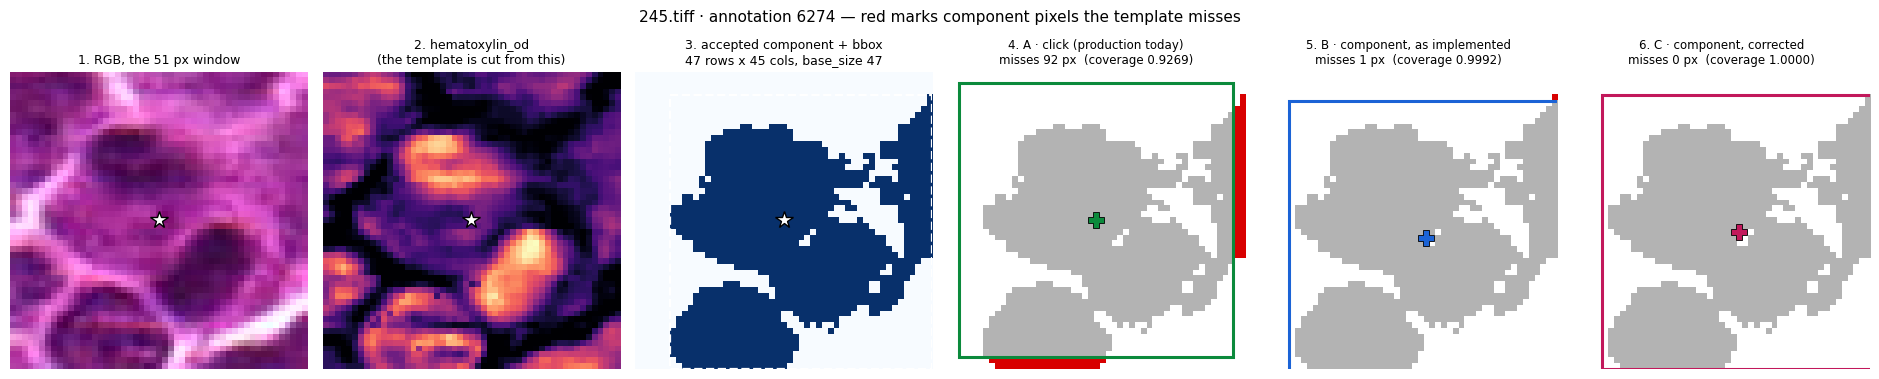

  -> figures_anchor/part8_245_walkthrough.png


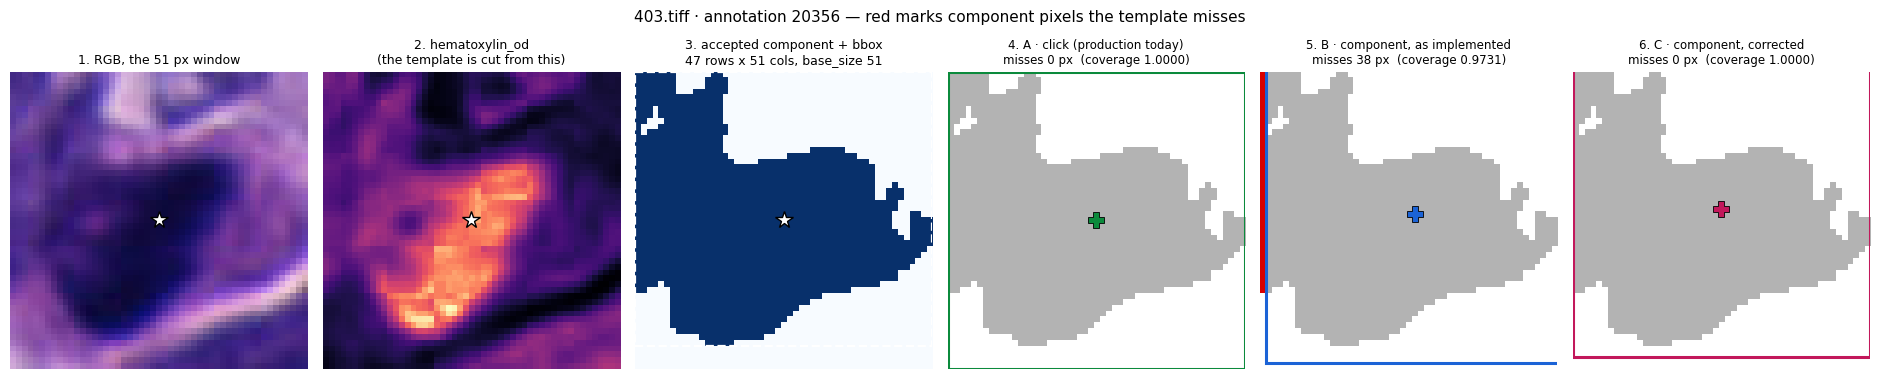

  -> figures_anchor/part8_403_walkthrough.png


In [11]:
def draw_seed(fn):
    s = SEEDS[fn]
    y0, y1, x0, x1 = s['bbox']
    S = s['base_size']
    fig, axes = plt.subplots(1, 3 + len(ARMS), figsize=(3.15 * (3 + len(ARMS)), 3.7))

    axes[0].imshow(s['rgb_patch'], interpolation='nearest')
    axes[0].set_title('1. RGB, the 51 px window', fontsize=9)
    axes[1].imshow(s['od_patch'], cmap='magma', interpolation='nearest')
    axes[1].set_title('2. hematoxylin_od\n(the template is cut from this)', fontsize=9)
    axes[2].imshow(s['mask'], cmap='Blues', interpolation='nearest')
    axes[2].add_patch(Rectangle((x0 - .5, y0 - .5), x1 - x0, y1 - y0, fill=False,
                                edgecolor='white', linewidth=1.6, linestyle='--'))
    axes[2].set_title(f'3. accepted component + bbox\n{y1-y0} rows x {x1-x0} cols, '
                      f'base_size {S}', fontsize=9)
    for ax in axes[:3]:
        ax.plot(HALF, HALF, marker='*', markersize=13, color='white', markeredgecolor='black')
        ax.axis('off')

    for k, a in enumerate(ARMS):
        ax = axes[3 + k]
        ax.imshow(s['mask'], cmap='Greys', alpha=0.30, interpolation='nearest')
        miss = s['missed'][a]
        rgba = np.zeros((*miss.shape, 4))
        rgba[miss] = (0.85, 0.0, 0.0, 1.0)
        ax.imshow(rgba, interpolation='nearest')
        ax_, ay_ = s['local'][a]
        r0, r1, c0, c1 = square_bounds(ax_, ay_, S)
        ax.add_patch(Rectangle((c0 - .5, r0 - .5), S, S, fill=False,
                               edgecolor=ARM_COLOR[a], linewidth=2.2))
        ax.plot(int(round(ax_)), int(round(ay_)), marker='P', markersize=11,
                color=ARM_COLOR[a], markeredgecolor='black', markeredgewidth=0.6)
        ax.set_title(f"{k+4}. {ARM_LABEL[a]}\nmisses {int(miss.sum())} px  "
                     f"(coverage {s['cover'][a]:.4f})", fontsize=8.5)
        ax.set_xlim(-0.5, W - 0.5); ax.set_ylim(W - 0.5, -0.5); ax.axis('off')

    fig.suptitle(f"{fn} · annotation {s['ann_id']} — red marks component pixels the template misses",
                 fontsize=11, y=1.03)
    fig.tight_layout()
    savefig(fig, f"part8_{fn.replace('.tiff','')}_walkthrough.png")


draw_seed('245.tiff')
draw_seed('403.tiff')

---

## Part 9 — The templates themselves

The panels above are masks — useful for reasoning, but not what the detector sees. These are the
actual arrays handed to `cv2.matchTemplate`: the `base_size` crop of `hematoxylin_od`, read at
each arm's own anchor, exactly as `build_augmentations` cuts it.

The bottom row is each arm's signed difference against arm C. A blank panel means the two arms
produced a byte-identical template, which happens when the rounding absorbs the half pixel.
Where it does not, the difference has the signature of a translation: bright on one side of every
edge, dark on the other.

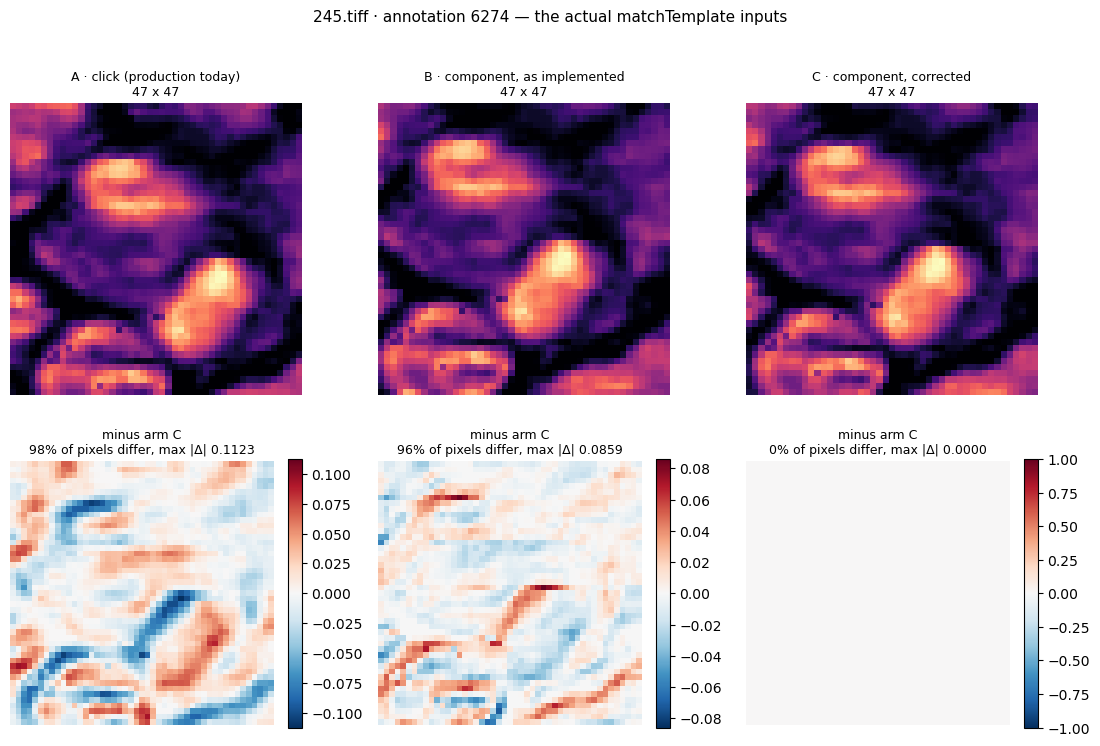

  -> figures_anchor/part9_245_templates.png


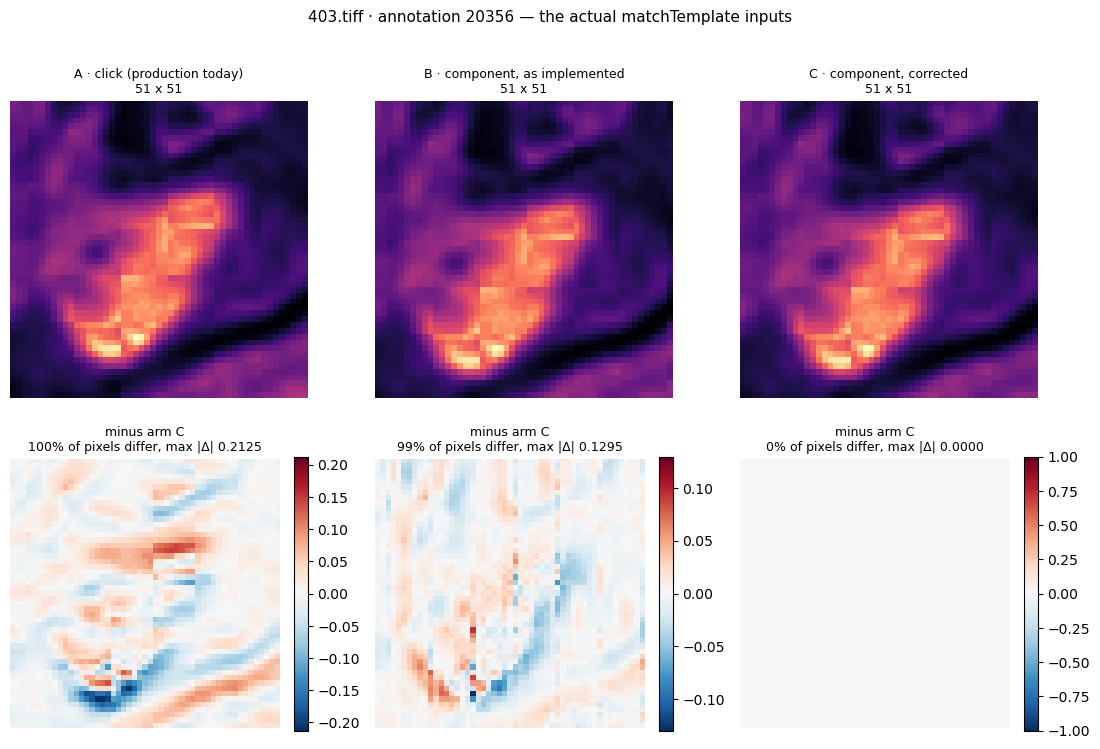

  -> figures_anchor/part9_403_templates.png


In [12]:
def draw_templates(fn):
    s = SEEDS[fn]
    S = s['base_size']
    tpl = {}
    for a in ARMS:
        p = s['tpl_patch'][a]                     # the 73 px read at this arm's anchor
        c, hb = p.shape[0] // 2, S // 2
        tpl[a] = p[c - hb:c + hb + 1, c - hb:c + hb + 1]
        assert tpl[a].shape == (S, S)

    fig, axes = plt.subplots(2, len(ARMS), figsize=(3.7 * len(ARMS), 7.5))
    vmin = min(float(t.min()) for t in tpl.values())
    vmax = max(float(t.max()) for t in tpl.values())
    ref = tpl['C_component_fixed']
    for k, a in enumerate(ARMS):
        axes[0][k].imshow(tpl[a], cmap='magma', vmin=vmin, vmax=vmax, interpolation='nearest')
        axes[0][k].set_title(f'{ARM_LABEL[a]}\n{S} x {S}', fontsize=9)
        axes[0][k].axis('off')
        d = tpl[a] - ref
        dmax = float(np.abs(d).max())
        im = axes[1][k].imshow(d, cmap='RdBu_r', vmin=-(dmax or 1.0), vmax=(dmax or 1.0),
                               interpolation='nearest')
        axes[1][k].set_title(f'minus arm C\n{float((np.abs(d) > 1e-9).mean()):.0%} of pixels '
                             f'differ, max |Δ| {dmax:.4f}', fontsize=9)
        axes[1][k].axis('off')
        fig.colorbar(im, ax=axes[1][k], fraction=0.046)
    fig.suptitle(f"{fn} · annotation {s['ann_id']} — the actual matchTemplate inputs",
                 fontsize=11, y=1.01)
    fig.tight_layout()
    savefig(fig, f"part9_{fn.replace('.tiff','')}_templates.png")


draw_templates('245.tiff')
draw_templates('403.tiff')

---

## Part 10 — The population: how often does this actually happen?

Two seeds are an illustration. This is the measurement.

The table below is over **all 896 gate-accepted annotations** across the 14 ROIs, and separately
over the **14 production seeds** — the ones that actually carry every committed `precision_at_k`
number in this repo.

Three columns to read:

- **full coverage** — the share of components the template contains *entirely*. This is the
  number arm C is designed to make 100%.
- **worst coverage** — the single worst case. How much of an object can this arm throw away?
- **median move** — how far the anchor sits from the click. This says whether the arms are even
  doing anything different in size terms; they are not — B and C move essentially the same
  distance, they just land on different pixels.

In [13]:
def summarise(df, label):
    rows = []
    for a in ARMS:
        cv, mv = df[f'cover_{a}'], df[f'move_{a}']
        rows.append(dict(population=label, arm=ARM_LABEL[a],
                         n=len(df),
                         full_coverage=f'{(cv == 1.0).mean():.1%}',
                         median_coverage=round(cv.median(), 4),
                         p10_coverage=round(cv.quantile(.10), 4),
                         worst_coverage=round(cv.min(), 4),
                         median_move_px=round(mv.median(), 2),
                         max_move_px=round(mv.max(), 2)))
    return pd.DataFrame(rows)


SEED_ROWS = POP[POP['ann_id'].isin([s['ann_id'] for s in SEEDS.values()])]
assert len(SEED_ROWS) == 14, len(SEED_ROWS)
TBL = pd.concat([summarise(POP, 'all gate-accepted (896)'),
                 summarise(SEED_ROWS, 'the 14 production seeds')], ignore_index=True)
display(TBL)

print('\nHow often each arm crops part of the validated component:')
for a in ARMS:
    n_all = int((POP[f'cover_{a}'] < 1.0).sum())
    n_seed = int((SEED_ROWS[f'cover_{a}'] < 1.0).sum())
    print(f'  {ARM_LABEL[a]:32s} {n_all:3d} / 896 accepted ({n_all/896:5.1%})   '
          f'{n_seed:2d} / 14 production seeds')
assert (POP['cover_C_component_fixed'] == 1.0).all(), \
    'arm C must cover every component completely -- that is its whole point'
print('\nASSERT PASSED: arm C covers every one of the 896 components completely.')

,population,arm,n,full_coverage,median_coverage,p10_coverage,worst_coverage,median_move_px,max_move_px
0,all gate-accepted (896),A · click (production today),896,28.2%,0.9864,0.8864,0.5563,0.00,0.00
1,all gate-accepted (896),"B · component, as implemented",896,60.5%,1.0000,0.9812,0.9321,3.04,13.65
2,all gate-accepted (896),"C · component, corrected",896,100.0%,1.0000,1.0000,1.0000,3.10,13.87
3,the 14 production seeds,A · click (production today),14,28.6%,0.9752,0.8903,0.8182,0.00,0.00
4,the 14 production seeds,"B · component, as implemented",14,35.7%,0.9985,0.9866,0.9731,2.15,7.81
5,the 14 production seeds,"C · component, corrected",14,100.0%,1.0000,1.0000,1.0000,2.52,8.52



How often each arm crops part of the validated component:
  A · click (production today)     643 / 896 accepted (71.8%)   10 / 14 production seeds
  B · component, as implemented    354 / 896 accepted (39.5%)    9 / 14 production seeds
  C · component, corrected           0 / 896 accepted ( 0.0%)    0 / 14 production seeds

ASSERT PASSED: arm C covers every one of the 896 components completely.


### Drawn: coverage per production seed

One row per ROI, one dot per arm. A dot at 1.0 means the template contains the whole validated
component. Arm C's dots are all at 1.0 — that is the guarantee from Part 5 holding on real data.

The gap between arm A and the others is the cost of centring on the click: on `246.tiff` the
production template misses roughly a fifth of the object the gate certified.

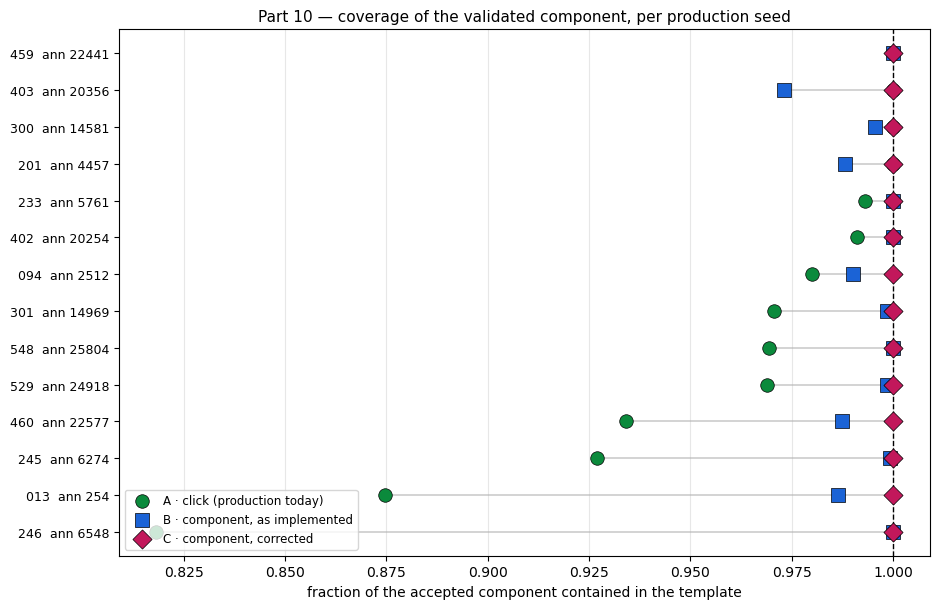

  -> figures_anchor/part10_seed_coverage.png


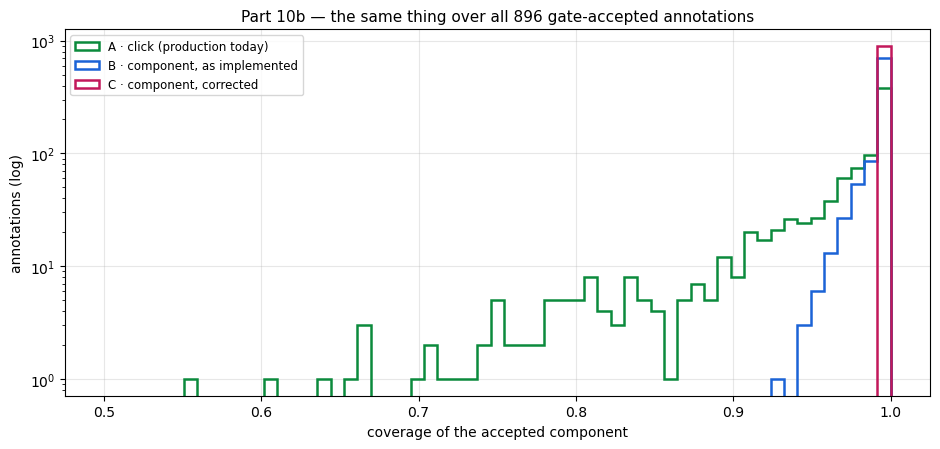

  -> figures_anchor/part10b_population_coverage.png


In [14]:
S14 = SEED_ROWS.sort_values('cover_A_click').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9.5, 6.2))
y = np.arange(len(S14))
for a in ARMS:
    ax.scatter(S14[f'cover_{a}'], y, s=95, color=ARM_COLOR[a], label=ARM_LABEL[a],
               edgecolor='black', linewidth=0.5, zorder=3,
               marker={'A_click': 'o', 'B_component_asis': 's', 'C_component_fixed': 'D'}[a])
for i, r in S14.iterrows():
    ax.plot([min(r[f'cover_{a}'] for a in ARMS), 1.0], [i, i], color='#ccc', lw=1.2, zorder=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{r['roi'].replace('.tiff','')}  ann {int(r['ann_id'])}"
                    for _, r in S14.iterrows()], fontsize=9)
ax.axvline(1.0, color='black', ls='--', lw=1)
ax.set_xlabel('fraction of the accepted component contained in the template')
ax.set_title('Part 10 — coverage of the validated component, per production seed', fontsize=11)
ax.legend(fontsize=8.5, loc='lower left'); ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
savefig(fig, 'part10_seed_coverage.png')

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for a in ARMS:
    ax.hist(POP[f'cover_{a}'], bins=np.linspace(0.5, 1.0, 60), histtype='step', lw=1.8,
            color=ARM_COLOR[a], label=ARM_LABEL[a])
ax.set_yscale('log')
ax.set_xlabel('coverage of the accepted component')
ax.set_ylabel('annotations (log)')
ax.set_title('Part 10b — the same thing over all 896 gate-accepted annotations', fontsize=11)
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
fig.tight_layout()
savefig(fig, 'part10b_population_coverage.png')

---

## Part 11 — Running the whole detector

Everything above is geometry: what the template contains. This part runs the actual pipeline on
`245.tiff` and `403.tiff` — one `matchTemplate` pass per arm, then peaks, NMS, ranking, and
precision at K = 10/20/30/50.

**Read this part as an illustration, not as evidence.** It is one seed per ROI on two ROIs. The
first notebook in this folder showed that a 4.3 px anchor move reshuffles thousands of candidates
packed into a narrow score band, so a single-seed precision@K difference is mostly ranking churn.
`DECISIONS.md` D5 sets the bar for this class of question — a 5-seed sweep with the paired delta
clustered at the ROI — and this is not that. What it *is* good for is seeing that the change
propagates all the way through, and seeing where the detections land.

Everything except the anchor is held fixed: `TM_CCOEFF`, `hematoxylin_od`, 8 augmentations,
deep floor `z = -1.5`, NMS radius = match radius = 7.5 µm, and `SELF_HIT_RADIUS = 10.0` for all
three arms. Because all three use the containment gate, they draw the **same annotation** on a
given ROI, so `gt_eval` is identical and the comparison is paired.

In [15]:
METHOD, PEAK_MIN_DISTANCE, DEEP_FLOOR_Z, MAX_PEAKS = cv2.TM_CCOEFF, 7, -1.5, 2_000_000
SELF_HIT_RADIUS = 10.0
BUDGETS = (10, 20, 30, 50)
E2E_ROIS = ('245.tiff', '403.tiff')


def suppress(centers, scores, radius, ref_xy):
    '''NMS at `radius`, then drop the template's own self-correlation.

    `ref_xy` is the point the TEMPLATE was built from, not the click -- the self-correlation
    peak lands wherever the template is centred (D8 "what it costs", item 1).
    '''
    keep = nms_by_distance(centers, scores, radius)
    c, s = centers[keep], scores[keep]
    if len(c):
        ok = np.hypot(c[:, 0] - ref_xy[0], c[:, 1] - ref_xy[1]) > SELF_HIT_RADIUS
        c, s = c[ok], s[ok]
    return c, s


def run_arm(arm, fn, hem, gt_eval, seed_click, anchor, match_radius, nms_radius, mpp, HW):
    base_size, ax, ay = anchor
    tpl_xy = (float(ax), float(ay))
    H, Wd = HW
    patch = tm.read_padded_patch(hem, *tpl_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hp = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fp, _, vp = tm.fused_response(hp, templates, CFG.scale_normalize, method=METHOD)
    fused, valid = fp[PAD:PAD + H, PAD:PAD + Wd], vp[PAD:PAD + H, PAD:PAD + Wd]
    assert bool(valid.all())
    med, mad = tm.robust_stats(fused, valid)
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE,
                                       med + DEEP_FLOOR_Z * mad, MAX_PEAKS)
    assert len(centers) < MAX_PEAKS
    fused_s = np.array(fused[::8, ::8], dtype=np.float32)
    del hp, fp, vp, fused, valid; gc.collect()

    c, s = suppress(centers, scores, nms_radius, tpl_xy)
    pool = pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s})
    n_annulus = int((np.hypot(pool['cx'] - tpl_xy[0], pool['cy'] - tpl_xy[1]) <= match_radius).sum())
    a = cp.Arm('tm_score_deep_floor', (lambda d=pool: d), rank_key='score', seeded=True,
               z=DEEP_FLOOR_Z, z_dependent=True, nms_radius=nms_radius, caps=(MAX_PEAKS,))
    out = cp.evaluate_arms([a], gt_eval, match_radius, roi_shape=(H, Wd), mpp=mpp,
                           budgets=BUDGETS, context=dict(file_name=fn, arm=arm), checks=[])
    ranked = cp._rank(pool, 'score')
    det, _ = ev.bucket_detections(ranked, gt_eval, match_radius)
    det = det.reset_index(drop=True); det['rank'] = np.arange(1, len(det) + 1)
    del centers, scores; gc.collect()
    return dict(arm=arm, fn=fn, base_size=base_size, tpl_xy=tpl_xy, det=det, out=out,
                med=float(med), mad=float(mad), fused_s=fused_s, n_annulus=n_annulus)


E2E, CTX = {}, {}
t0 = time.time()
for fn in E2E_ROIS:
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path); mpp = ds.roi_mpp(path)
    hem, gi = ch.to_channel(rgb, 'hematoxylin_od'), ch.to_gray_inverted(rgb)
    H, Wd = hem.shape[:2]
    mr, nr = ev.radius_px(mpp, ev.MIDOG_RADIUS_UM), ev.radius_px(mpp, ev.MIDOG_RADIUS_UM)
    s = SEEDS[fn]
    gt = ds.image_annotations(ANNS, fn)
    gt_eval = gt[gt['ann_id'] != s['ann_id']].reset_index(drop=True)   # GT never moves
    CTX[fn] = dict(gt=gt, gt_eval=gt_eval, mpp=mpp, match_radius=mr,
                   rgb_small=np.array(rgb[::4, ::4]), click=s['click'],
                   n_gt=int((gt_eval['category_id'] == ds.MITOTIC).sum()))
    del rgb, gi; gc.collect()
    for a in ARMS:
        E2E[(fn, a)] = run_arm(a, fn, hem, gt_eval, s['click'], s['glob'][a], mr, nr, mpp, (H, Wd))
        r = E2E[(fn, a)]
        print(f"  [{fn} {ARM_LABEL[a]:30s}] base={r['base_size']:2d} "
              f"tpl=({r['tpl_xy'][0]:.1f}, {r['tpl_xy'][1]:.1f}) "
              f"n_det={len(r['det']):6d} annulus={r['n_annulus']}", flush=True)
    del hem; gc.collect()
print(f'\n{len(E2E)} runs in {time.time()-t0:.0f}s')

  [245.tiff A · click (production today)  ] base=47 tpl=(6356.0, 535.0) n_det= 19191 annulus=0


  [245.tiff B · component, as implemented ] base=47 tpl=(6359.5, 537.5) n_det= 18790 annulus=0


  [245.tiff C · component, corrected      ] base=47 tpl=(6359.0, 537.0) n_det= 19114 annulus=0


  [403.tiff A · click (production today)  ] base=51 tpl=(2227.0, 2970.0) n_det= 16689 annulus=0


  [403.tiff B · component, as implemented ] base=51 tpl=(2227.5, 2968.5) n_det= 16406 annulus=0


  [403.tiff C · component, corrected      ] base=51 tpl=(2227.0, 2968.0) n_det= 16508 annulus=0



6 runs in 242s


### Precision at each budget

`tp_at_budget` is how many of the top-K candidates matched a real mitotic figure; precision is
that over K. All three arms score against the same ground truth, with the seed's own annotation
excluded.

,roi,arm,base_size,tpl_x,tpl_y,n_detections,tp@10,prec@10,tp@20,prec@20,tp@30,prec@30,tp@50,prec@50
0,245.tiff,A · click (production today),47,6356.0,535.0,19191,0,0.0,2,0.10,2,0.067,3,0.06
1,245.tiff,"B · component, as implemented",47,6359.5,537.5,18790,1,0.1,1,0.05,1,0.033,1,0.02
2,245.tiff,"C · component, corrected",47,6359.0,537.0,19114,1,0.1,1,0.05,1,0.033,2,0.04
3,403.tiff,A · click (production today),51,2227.0,2970.0,16689,4,0.4,8,0.40,11,0.367,15,0.30
4,403.tiff,"B · component, as implemented",51,2227.5,2968.5,16406,4,0.4,8,0.40,11,0.367,14,0.28
5,403.tiff,"C · component, corrected",51,2227.0,2968.0,16508,4,0.4,8,0.40,12,0.400,14,0.28


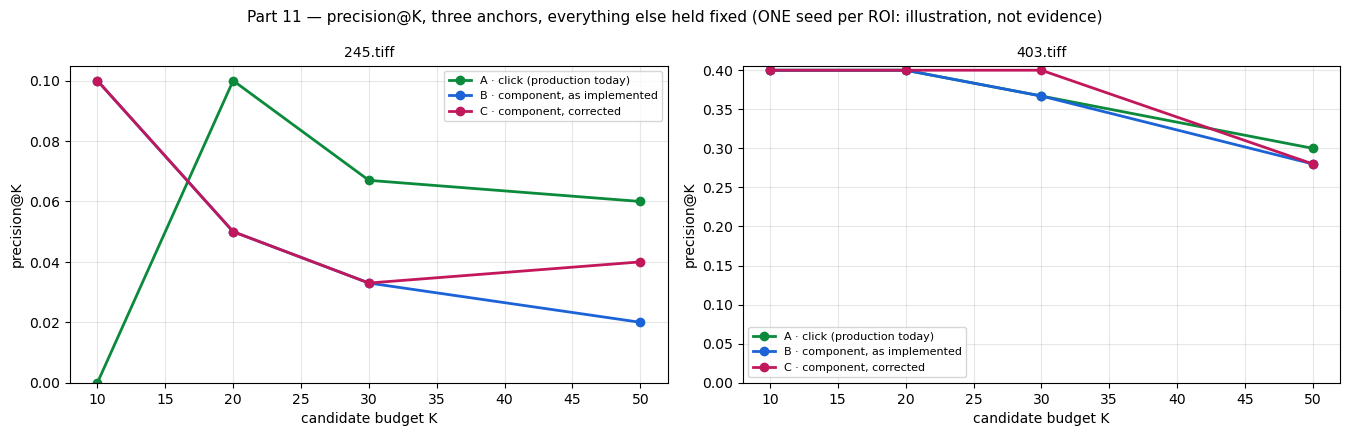

  -> figures_anchor/part11_precision_at_k.png


In [16]:
rows = []
for (fn, a), r in E2E.items():
    o = r['out']
    d = dict(roi=fn, arm=ARM_LABEL[a], base_size=r['base_size'],
             tpl_x=round(r['tpl_xy'][0], 1), tpl_y=round(r['tpl_xy'][1], 1),
             n_detections=len(r['det']))
    for k in BUDGETS:
        tp = int(o.loc[o['budget'] == k, 'tp_at_budget'].iloc[0])
        d[f'tp@{k}'], d[f'prec@{k}'] = tp, round(tp / k, 3)
    rows.append(d)
E2E_TBL = pd.DataFrame(rows).sort_values(['roi', 'arm'])
display(E2E_TBL)

fig, axes = plt.subplots(1, len(E2E_ROIS), figsize=(6.8 * len(E2E_ROIS), 4.4), squeeze=False)
for ax, fn in zip(axes[0], E2E_ROIS):
    for a in ARMS:
        row = E2E_TBL[(E2E_TBL['roi'] == fn) & (E2E_TBL['arm'] == ARM_LABEL[a])]
        ax.plot(BUDGETS, [float(row[f'prec@{k}'].iloc[0]) for k in BUDGETS], marker='o',
                lw=2, color=ARM_COLOR[a], label=ARM_LABEL[a])
    ax.set_xlabel('candidate budget K'); ax.set_ylabel('precision@K')
    ax.set_title(fn, fontsize=10); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)
fig.suptitle('Part 11 — precision@K, three anchors, everything else held fixed '
             '(ONE seed per ROI: illustration, not evidence)', fontsize=11)
fig.tight_layout()
savefig(fig, 'part11_precision_at_k.png')

### Where the top 50 land

Detections coloured by the repo's three outcome buckets: a hit (`human_correct_label`), a
pathologist-rejected look-alike (`human_rejected_label`), or unannotated tissue
(`non_human_findings`). Circles are drawn at the true match radius, so what you see is what the
scorer counts. The white star is the click; the coloured cross is where that arm built its
template.

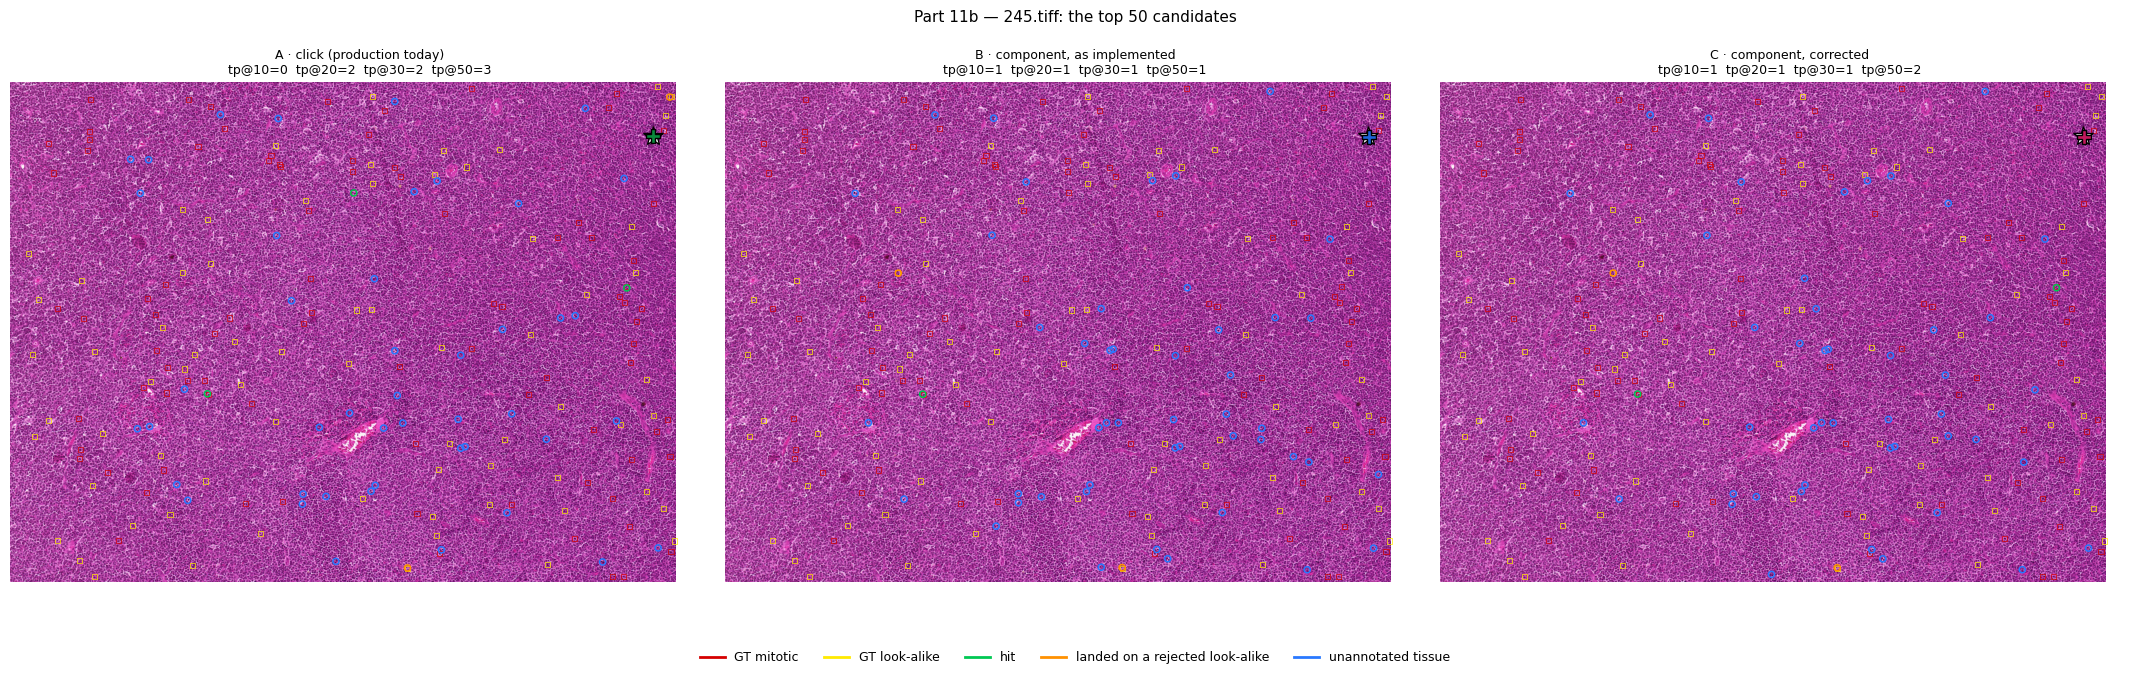

  -> figures_anchor/part11b_245_top50.png


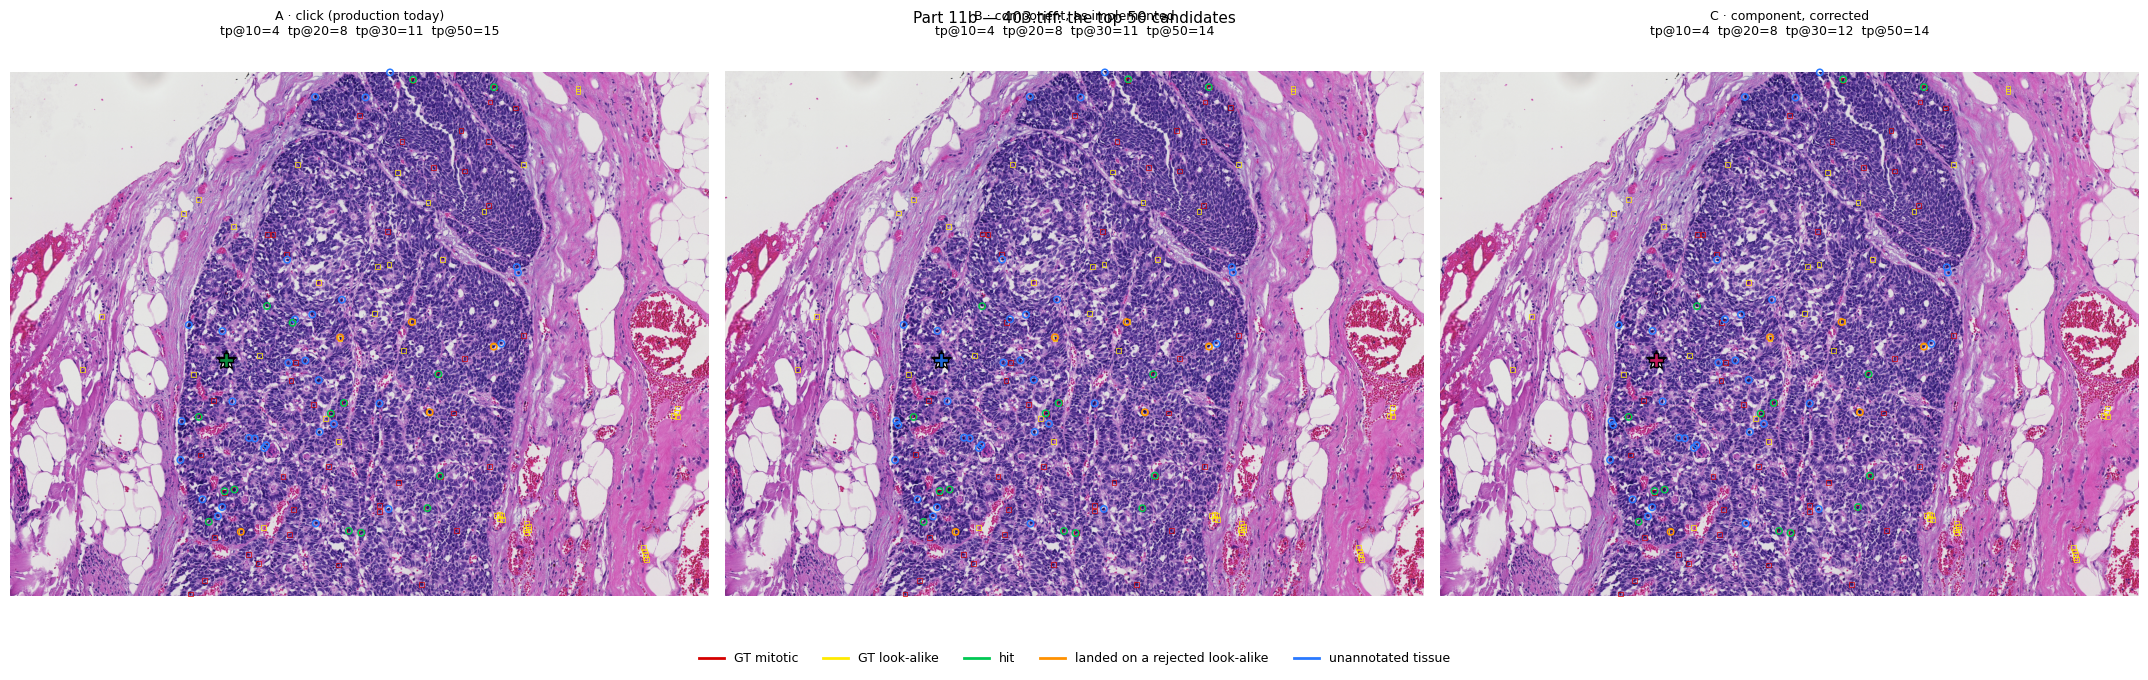

  -> figures_anchor/part11b_403_top50.png


In [17]:
for fn in E2E_ROIS:
    c = CTX[fn]
    fig, axes = plt.subplots(1, len(ARMS), figsize=(7.2 * len(ARMS), 6.4))
    for ax, a in zip(axes, ARMS):
        r = E2E[(fn, a)]
        ax.imshow(c['rgb_small'])
        sc = 0.25
        for _, g in c['gt'].iterrows():
            col = '#d50000' if g['category_id'] == ds.MITOTIC else '#ffea00'
            ax.add_patch(Rectangle(((g['cx'] - 25) * sc, (g['cy'] - 25) * sc), 50 * sc, 50 * sc,
                                   fill=False, edgecolor=col, linewidth=0.5))
        for _, d in r['det'].head(50).iterrows():
            ax.add_patch(Circle((d['cx'] * sc, d['cy'] * sc), radius=c['match_radius'] * sc,
                                fill=False, edgecolor=viz.BUCKET_COLORS[d['bucket']], linewidth=1.1))
        ax.plot(c['click'][0] * sc, c['click'][1] * sc, marker='*', markersize=15,
                color='white', markeredgecolor='black')
        ax.plot(r['tpl_xy'][0] * sc, r['tpl_xy'][1] * sc, marker='P', markersize=10,
                color=ARM_COLOR[a], markeredgecolor='black')
        o = r['out']
        ax.set_title(f"{ARM_LABEL[a]}\n" + '  '.join(
            f"tp@{k}={int(o.loc[o['budget']==k,'tp_at_budget'].iloc[0])}" for k in BUDGETS),
            fontsize=9)
        ax.axis('off')
    fig.legend(handles=[
        Line2D([], [], color='#d50000', lw=2, label='GT mitotic'),
        Line2D([], [], color='#ffea00', lw=2, label='GT look-alike'),
        Line2D([], [], color=viz.BUCKET_COLORS[ev.HUMAN_CORRECT_LABEL], lw=2, label='hit'),
        Line2D([], [], color=viz.BUCKET_COLORS[ev.HUMAN_REJECTED_LABEL], lw=2,
               label='landed on a rejected look-alike'),
        Line2D([], [], color=viz.BUCKET_COLORS[ev.NON_HUMAN_FINDINGS], lw=2,
               label='unannotated tissue')],
        loc='lower center', ncol=5, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.06))
    fig.suptitle(f'Part 11b — {fn}: the top 50 candidates', fontsize=11)
    fig.tight_layout()
    savefig(fig, f"part11b_{fn.replace('.tiff','')}_top50.png")

---

## Part 12 — What this notebook shows, and what it does not

### Shown, and proven rather than argued

1. **`tightened_template_box` computes its anchor half a pixel too far down and right.** It takes
   `(x0 + x1) / 2` of a half-open bounding box — the centre of the *area* the box spans — and
   hands it to `read_padded_patch`, which rounds it and treats it as naming a *pixel*. Part 3
   verifies this against the live function on a synthetic rectangle whose true centre is known by
   construction.

2. **Half a pixel becomes a whole pixel about half the time.** Python's `round` breaks `.5` ties
   toward even, so the extra 0.5 either vanishes or displaces the anchor by a full pixel,
   depending only on the parity of the box's true centre (Part 4).

3. **The correction restores a guarantee.** Because `base_size = _odd(max(h, w)) ≥ max(h, w)`, a
   square of that side centred on the box's *pixel* centre always contains the entire box. Part 5
   checks this exhaustively over every box shape from 1×1 to 51×51; arm C never clips, arm B
   does. On the real 896 gate-accepted components, arm C covers every one completely.

4. **It reaches the seeds that matter.** Arm B crops part of the validated component on 9 of the
   14 seeds behind every committed `precision_at_k` number in this repo.

5. **Centring on the click costs the most coverage of all.** Arm A — production today — contains
   the whole component on only a minority of accepted annotations, and on `246.tiff` its template
   misses about a fifth of the object the gate had just certified. That is a real, measured cost
   of the click-centred configuration, and it is the strongest empirical support for recentring
   that exists in this repo.

### Not shown

**That any of this changes precision@K.** Part 11 is one seed per ROI on two ROIs. The bias is
0.707 px against a median recentring distance of about 3.1 px — roughly a quarter of the signal,
pointing consistently one way — which means `DECISIONS.md` D8's 2026-09-09 amendment measured a
contaminated quantity. It does **not** mean the amendment reached the wrong answer. Arm C has
never been compared against arm A at the bar D5 sets.

**That coverage is the right objective.** The template carries surrounding context as well as the
object, and the click is where ground truth is scored — so trading GT alignment for component
coverage may not pay. Nothing here adjudicates that.

### The next step

Fix the anchor first, because it is strictly dominant and justified independently of the
recentring question — arm C is arm B's intent, correctly implemented, at no cost. Then run the
comparison D8's amendment asked for and never got: **arm A against arm C, 5 seeds × 14 ROIs,
paired delta clustered at the ROI, `SELF_HIT_RADIUS` matched.** That is the clean test of whether
aligning the template to the validated object helps, and it has never been run.

Note that fixing the anchor changes the committed `production_seed_precision_at_k*` numbers: 12
of the 14 seeds move.

In [18]:
print(f'notebook wall clock: {time.time() - NB_T0:.0f}s')
print(f'figures written to {FIGDIR}/: {len(os.listdir(FIGDIR))}')
POP.to_csv('artifacts/anchor_population.csv', index=False)
SEED_ROWS.to_csv('artifacts/anchor_production_seeds.csv', index=False)
E2E_TBL.to_csv('artifacts/anchor_end_to_end.csv', index=False)
print('artifacts: anchor_population.csv, anchor_production_seeds.csv, anchor_end_to_end.csv')

notebook wall clock: 406s
figures written to figures_anchor/: 10


artifacts: anchor_population.csv, anchor_production_seeds.csv, anchor_end_to_end.csv
